In [ ]:
!pip install enoslib ipywidgets

In [ ]:
!ssh rennes.grid5000.fr hostname

frennes


: 

### Building and pushing the docker images to dockerhub

In [6]:
!/home/corentin/fcquic_applications_master_thesis/docker_images/build_images.sh

Building base image

[+] Building 0.0s (0/1)                                          docker:default
[+] Building 0.2s (1/2)                                          docker:default
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 1.47kB                                     0.0s
 => [internal] load metadata for docker.io/library/debian:bookworm-slim    0.2s
[+] Building 0.3s (1/2)                                          docker:default
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 1.47kB                                     0.0s
 => [internal] load metadata for docker.io/library/debian:bookworm-slim    0.3s
[+] Building 0.3s (1/3)                                          docker:default
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 1.47kB                                     0.0s
 => [internal] load

In [7]:
!/home/corentin/fcquic_applications_master_thesis/docker_images/upload_images.sh

tagging and pushing base
The push refers to repository [docker.io/corentindetry/base]

596775ab: Waiting 
05cab8af: Waiting 
1c60fe54: Waiting 
17e0a25e: Waiting 
afebaf4d: Waiting 
12bd67ef: Waiting 
1b5e9776: Waiting 
b238bc9a: Waiting 
fca4d5c8: Waiting 
53f2dec3: Waiting 
afebaf4d: Pushed   28.24MB/28.24MBlatest: digest: sha256:0308cb2372889b6fd56fbf9c38f15d6f26c9dc699be822f089a85bc85e56e8d7 size: 856
tagging and pushing fcquic_client
The push refers to repository [docker.io/corentindetry/fcquic_client]

fe8e9fb7: Waiting 
12bd67ef: Waiting 
32e7cfef: Waiting 
fca4d5c8: Waiting 
53f2dec3: Waiting 
17e0a25e: Waiting 
1b5e9776: Waiting 
be19fd1f: Waiting 
890ea33a: Waiting 
afebaf4d: Waiting 
1c60fe54: Waiting 
b238bc9a: Waiting 
2e7cfef: Pushed   1.287kB/1.287kBry/base Klatest: digest: sha256:f4d846e0c94c27c0a79b49f3469fc7dd1cd475a9bb66be3b5beabbfad83ec181 size: 856
tagging and pushing fcquic_server
The push refers to repository [docker.io/corentindetry/fcquic_server]

d544bb48: Wai

### G5K connection

Setup the `.python-grid5000.yaml` file with the username and password used to login to grid5000.

The file should look like this:
```yaml
username: G5K_LOGIN
password: G5K_password
```

-> required in order for the enoslib calls to g5k to work.

In addition to this, make sure to add these lines to your ssh configuration:

```text
Host g5k
    User G5K_LOGIN
    HostName access.grid5000.fr
    ForwardAgent no

Host !access.grid5000.fr *.grid5000.fr
    User G5K_LOGIN
    ProxyJump G5K_LOGIN@access.grid5000.fr
    StrictHostKeyChecking no
    UserKnownHostsFile /dev/null
    ForwardAgent yes

Host access.grid5000.fr
    User G5K_LOGIN
    StrictHostKeyChecking no
    UserKnownHostsFile /dev/null
    ForwardAgent yes

Host *.g5k
    User G5K_LOGIN
    ProxyCommand ssh g5k -W "$(basename %h .g5k):%p"
    ForwardAgent no
```

Make sure to replace `G5K_LOGIN` with your g5k username (the one from the site)

In [2]:
import os
from grid5000 import Grid5000

conf_file = os.path.join(os.environ.get("HOME"), ".python-grid5000.yaml")
gk = Grid5000.from_yaml(conf_file)

print("Sites: ")
display(gk.sites.list())

Sites: 


[<Site uid:bordeaux>,
 <Site uid:grenoble>,
 <Site uid:lille>,
 <Site uid:louvain>,
 <Site uid:luxembourg>,
 <Site uid:lyon>,
 <Site uid:nancy>,
 <Site uid:nantes>,
 <Site uid:rennes>,
 <Site uid:sophia>,
 <Site uid:strasbourg>,
 <Site uid:toulouse>]

### Job configuration

Setup the various parameters for the job:
- The job name will identify the current booking, if the notebook kernel dies, re running the same reservation code with the same name will reload the existing job instead of booking a new one
- The walltime is the time that the booking will last, you can always stop your reservation earlier than the booking's end time

In [1]:
# JOB_NAME="fcquic_multisite_GRE_testing"
JOB_NAME="fcquic_netns_eval_test"
JOB_WALLTIME="1:0:00"
SERVER_CLUSTER="larochette"
CLIENT_CLUSTER="ecotype"
KAVLAN_SITE="nantes"
NUM_SERVER_NODES=1
NUM_CLIENT_NODES=0

### Create the booking

This first case will only create the booking object locally, but not yet place the booking.

You can adjust the different roles of the machines to match the roles defined in the NPF script.

For example, here I have 2 roles: server and client. The server node will run the server section of the NPF script,...

In [3]:
import enoslib as en
import logging

# Display some general information about the library
en.check()
# Enable rich logging
_ = en.init_logging()
# en.set_config(g5k_auto_jump=False)

# private_net = en.G5kNetworkConf(type="kavlan-global", roles=["global"], site=KAVLAN_SITE)
conf = (
    en.G5kConf.from_settings(
        job_name=JOB_NAME,
        walltime=JOB_WALLTIME,
        env_name="ubuntu2404-nfs",
        job_type=["deploy"],
    )

    # .add_network_conf(private_net)
    .add_machine(
        roles=["server"],
        cluster=SERVER_CLUSTER,
        nodes=NUM_SERVER_NODES,
        # secondary_networks=[private_net]
    ) 
    # .add_machine(
    #     roles=["client"],
    #     cluster=CLIENT_CLUSTER, 
    #     nodes=NUM_CLIENT_NODES,
    #     # secondary_networks=[private_net]
    # )
)
#     .add_network(
#     id="custom_subnet",
#     type="slash_22",
#     roles=["custom_subnet"],
#     site=KAVLAN_SITE,
# )

# This will validate the configuration, but not reserve resources yet
provider = en.G5k(conf)

[WARNING]: failed to patch stdout/stderr for fork-safety: 'OutStream' object
has no attribute 'buffer'
[WARNING]: failed to reconfigure stdout/stderr with custom encoding error
handler: 'OutStream' object has no attribute 'reconfigure'


_____        ___  ____  _ _ _
 | ____|_ __  / _ \/ ___|| (_) |__
 |  _| | '_ \| | | \___ \| | | '_ \
 | |___| | | | |_| |___) | | | |_) |
 |_____|_| |_|\___/|____/|_|_|_.__/  10.6.0

 • Documentation: ]8;id=692529;https://discovery.gitlabpages.inria.fr/enoslib/\https://discovery.gitlabpages.inria.fr/enoslib/]8;;\                            
 • Source: ]8;id=6812;https://gitlab.inria.fr/discovery/enoslib\https://gitlab.inria.fr/discovery/enoslib]8;;\                                         
 • Chat: ]8;id=310235;https://framateam.org/enoslib\https://framateam.org/enoslib]8;;\

                         Dependency check                         
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Provider      ┃    Status     ┃ Hint                           ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Chameleon     │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ ChameleonKVM  │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ ChameleonEdge │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ Fabric        │ NOT INSTALLED │ pip install enoslib[fabric]    │
│ Distem        │ NOT INSTALLED │ pip install enoslib[distem]    │
│ IOT-lab       │ NOT INSTALLED │ pip install enoslib[iotlab]    │
│ Grid'5000     │   INSTALLED   │                                │
│ Openstack     │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ Vagrant       │ NOT INSTALLED │ pip install enoslib[vagrant]   │
│ VMonG5k       │   INSTALLED   │                                │
└───────────────┴───────────────┴────────────────────────────────┘

                                Connectivity check                                 
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Provider  ┃ Key                 ┃ Connectivity ┃ Hint                           ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Grid'5000 │ ssh:access          │      ✅      │ Connection to access.grid5000… │
│ Grid'5000 │ ssh:access:frontend │      ✅      │ Connection Host(rennes.grid50… │
│ Grid'5000 │ api:access          │      ✅      │                                │
│ VMonG5k   │ access              │      ❔      │ Check G5k status               │
└───────────┴─────────────────────┴──────────────┴────────────────────────────────┘

In [4]:
print("Reserving resources...")

# Get actual resources
roles, networks = provider.init()
display(roles)
display(networks)

Reserving resources...


INFO     [G5k] Reloading 277588 from luxembourg                          ]8;id=439774;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=312488;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Waiting for 5 seconds before next OAR job(s) check...     ]8;id=151388;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=283196;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#337\337]8;;\

INFO     [G5k] Job 277588 on luxembourg: scheduled for 2026-03-24        ]8;id=771270;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=348785;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#345\345]8;;\
         18:32:58                                                                            

INFO     [G5k] All jobs are Running !                                    ]8;id=339854;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=260919;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#356\356]8;;\

...

Finished 1 tasks (Run dhcp on the nodes) on {'larochette-3.luxembourg.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

{'server': {Host(address='larochette-3.luxembourg.grid5000.fr', alias='larochette-3.luxembourg.grid5000.fr', user='root', keyfile=None, port=None, extra={'gateway': 'access.grid5000.fr', 'gateway_user': 'cdetry'}, net_devices=set(), _Host__original_extra={'gateway': 'access.grid5000.fr', 'gateway_user': 'cdetry'})}}

WARNING  [G5k] gateway is not yet implemented for <class                       ]8;id=348235;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/objects.py\objects.py]8;;\:]8;id=84677;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/objects.py#780\780]8;;\
         'enoslib.infra.enos_g5k.objects.G5kEnosProd6Network'> on the G5k side               

{'prod': {<enoslib.infra.enos_g5k.objects.G5kEnosProd4Network object at 0x75a6880a54c0>, <enoslib.infra.enos_g5k.objects.G5kEnosProd6Network object at 0x75a671eae930>}}

Don't forget to do `ssh-add .ssh/id_ed25519` to make the connection work

In [5]:
with en.actions(roles=roles) as a:
    a.apt(task_name="Install openjdk", name="openjdk-11-jre", state="present")
    results = a.results

Output()

Finished 1 tasks (Install openjdk) on {'larochette-3.luxembourg.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

In [ ]:
!ssh-add ~/.ssh/id_ed25519

.ssh/id_ed25519: No such file or directory


In [11]:
from itertools import islice, product

# distribute some virtual ips
# N = 1
# ips = networks["custom_subnet"][0].free_ips

# for host in roles["client"]:
#     host.extra.update(ips=[str(ip) for ip in islice(ips, N)])

# with en.play_on(roles=roles, gather_facts=False) as p:
#     p.shell(
#         "(ip a | grep {{ item }}) || ip addr add {{ item }}/22 dev eno1",
#         loop="{{ ips }}",
#     )

roles = en.sync_info(roles, networks)
    

Output()

Finished 1 tasks (Waiting for connection) on {'chiclet-7.lille.grid5000.fr', 
'ecotype-8.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Finished 7 tasks (Gathering Facts,setup,utils : include_tasks,utils : Dump network 
information in a file,utils : Create the fake interfaces) on {'chiclet-7.lille.grid5000.fr', 
'ecotype-8.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

In [12]:
# From: https://discovery.gitlabpages.inria.fr/enoslib/tutorials/grid5000.html#kavlan-on-secondary-interfaces
# Fill in network information from nodes
# roles = en.sync_info(roles, networks)

for host in roles["client"] + roles["server"]:
    # Find out which physical interface is connected to Kavlan network
    interfaces = host.filter_interfaces(networks=networks["global"])
    assert len(interfaces) == 1
    interface_name = interfaces[0]
    # Set MTU to 9000
    cmd = f"ip link set {interface_name} mtu 9000"
    en.run_command(cmd, task_name=cmd, roles=host, gather_facts=False)

Output()

Finished 1 tasks (ip link set eno2 mtu 9000) on {'ecotype-8.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Finished 1 tasks (ip link set enp98s0f1 mtu 9000) on {'chiclet-7.lille.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

In [13]:
data = {}
for node_role, hosts_data in roles.items():
    for host_data in hosts_data:

        ip_address_obj = None
        if len(host_data.filter_addresses(networks=networks["global"])) == 0:
            br0_addresses = list([device.addresses for device in host_data.net_devices if device.name == "enp1s0f0np0"][0])
            display(br0_addresses)

            ip_address_obj = br0_addresses[1]
        else:
            # Get each node's IP address on the private network
            # ip_address_obj = host_data.filter_addresses(networks=networks["global"])[0]
            ip_address_obj = host_data.filter_addresses(networks=networks["custom_subnet"])[0]

        # This may seem weird: ip_address_obj.ip is a `netaddr.IPv4Interface`
        # which itself has an `ip` attribute.
        node_ip = ip_address_obj.ip.ip
        if data.get(node_role) is None:
           data[node_role] = []
        data[node_role].append(node_ip.exploded)

        # display(node_ip)

display(data)
print(f"Server IP: {data["server"][0]}")

{'server': ['10.47.196.157'], 'client': ['172.16.193.8']}

Server IP: 10.47.196.157


### Docker installation
Nodes don't have docker installed by default. Run `g5k-setup-docker -t` on every node to do so.

Could also use enoslib's [docker service](https://discovery.gitlabpages.inria.fr/enoslib/apidoc/docker.html#docker-service)

In [22]:
# runs on all nodes with the given roles and installs docker

with en.play_on(roles=roles) as p:
    p.shell('g5k-setup-docker -t')  

Output()

Finished 1 tasks (shell) on {'spirou-3.louvain.grid5000.fr', 'gros-124.nancy.grid5000.fr', 
'gros-22.nancy.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

In [ ]:
# TODO: use https://github.com/Emilevillette/enoslib-fastclick-test/blob/16d1155aa11ce1c5025bdce24476d3f3388cbb92/energy-scheduling/run-npf.py#L234
# to be able to set each client's IP directly from python here, and not make the clients fetch their local ip themselves

In [9]:
display(roles)

ip
10.47.196.155/18 # noqa
fe80::3efd:feff:fec1:6fe1/64 # noqa
ip
fe80::3efd:feff:fec1:6fe0/64 # noqa
172.16.39.5/20 # noqa
ip
127.0.0.1/8 # noqa
::1/128 # noqa
ip
10.47.241.108/18 # noqa


### Compiling and pushing binaries with SCP

In [10]:
!cd /home/corentin/fcquic_applications_master_thesis/fcquic_chat && cargo build --release 

   --> /home/corentin/fcquic_applications_master_thesis/multicast-quic/octets/src/lib.rs:474:22
    |
474 |     pub fn get_bytes(&mut self, len: usize) -> Result<Octets> {
    |                      ^^^^^^^^^                        ^^^^^^ the same lifetime is hidden here
    |                      |
    |                      the lifetime is elided here
    |
    = help: the same lifetime is referred to in inconsistent ways, making the signature confusing
    = note: `#[warn(mismatched_lifetime_syntaxes)]` on by default
help: use `'_` for type paths
    |
474 |     pub fn get_bytes(&mut self, len: usize) -> Result<Octets<'_>> {
    |                                                             ++++

   --> /home/corentin/fcquic_applications_master_thesis/multicast-quic/octets/src/lib.rs:491:26
    |
491 |     pub fn get_bytes_mut(&mut self, len: usize) -> Result<OctetsMut> {
    |                          ^^^^^^^^^                        ^^^^^^^^^ the same lifetime is hidden here
    | 

In [13]:
import subprocess

cert_dir = "/home/corentin/fcquic_applications_master_thesis/fcquic_chat"
# cert_dir = "/home/corentin/FFSexp3-master-thesis/multicast"
local_bin_dir = f"{cert_dir}/target/release"
remote_bin_dir = "/home/cdetry"

for role, nodes in roles.items():
    for node in nodes:
        host = node.address
        print(f"pushing binary to {host} (role: {role})")
    
        subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/bin"], check=True)
        subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/logs/client"], check=True)
        subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/logs/server"], check=True)
        
        # subprocess.run(["scp", f"{local_bin_dir}/source", f"{host}:{remote_bin_dir}/bin/source"], check=True)
        # subprocess.run(["scp", f"{local_bin_dir}/receiver", f"{host}:{remote_bin_dir}/bin/receiver"], check=True)
        subprocess.run(["scp", f"{local_bin_dir}/server", f"{host}:{remote_bin_dir}/bin/server"], check=True)
        subprocess.run(["scp", f"{local_bin_dir}/client", f"{host}:{remote_bin_dir}/bin/client"], check=True)
        subprocess.run(["scp", f"{cert_dir}/cert.crt", f"{host}:{remote_bin_dir}/cert.crt"], check=True)
        subprocess.run(["scp", f"{cert_dir}/cert.key", f"{host}:{remote_bin_dir}/cert.key"], check=True)
        
print("pushed binaries to all nodes")

pushing binary to chiclet-5.lille.grid5000.fr (role: server)


pushing binary to ecotype-8.nantes.grid5000.fr (role: client)


pushed binaries to all nodes


### Running the experiment

In [14]:
import datetime
from npf import enoslib as enoslib
import npf.globals
from importlib import reload

reload(npf)
reload(enoslib)

# IMPORTANT: if you run this cell multiple times, you must clear the global roles dictionary kept by NPF otherwise it will keep appending the nodes to it and this dict. will keep growing
# leading to each client being ran multiple times....
npf.globals.roles.clear()

print("Launching NPF")
now = str(datetime.datetime.now())
results, _ = enoslib.run(
    "test_quic.npf",
    # Don't use series, it kinda breaks the whole test
    # series=[
    #     f"local",
    # ], 
    argsv= [
        "--single-output",
        f"./npf-out/{now}.csv",
        "--no-graph",
        f"--variables",
            f"SERVER_IP={data["server"][0]}", 
            f"CLIENT_IPS=({" ".join(data["client"])})",
            f'USE_DOCKER="false"',
    ],
    roles=roles,
)

Launching NPF
cluster/localhost.node could not be found, we will connect to localhost with SSH using default parameters
cluster/chiclet-5.lille.grid5000.fr.node could not be found, we will connect to chiclet-5.lille.grid5000.fr with SSH using default parameters
cluster/ecotype-8.nantes.grid5000.fr.node could not be found, we will connect to ecotype-8.nantes.grid5000.fr with SSH using default parameters
[Local] Running test test_quic.npf...
FCQUIC vs QUIC vs TCP (with TLS)
Executing init scripts...


Output()

Output()

Finished 1 tasks ( bash -c 'mkdir -p test2603171852-14294 && cd test2603171852-14294;
sudo-g5k
sudo sysctl -w net.core.rmem_max=26214400
sudo sysctl -w net.core.rmem_max=26214400


') on {'chiclet-5.lille.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

server [0] net.core.rmem_max = 26214400
server [0] net.core.rmem_max = 26214400


Finished 1 tasks ( bash -c 'mkdir -p test2603171852-14294 && cd test2603171852-14294;
sudo-g5k
sudo sysctl -w net.core.rmem_max=26214400
sudo sysctl -w net.core.rmem_max=26214400



') on {'ecotype-8.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

client [0] net.core.rmem_max = 26214400
client [0] net.core.rmem_max = 26214400
INTERVAL = 100, LAMBDA = 0.1, NUM_CLIENTS = 1, MIN = 1, TEST_LENGTH = 10, FAL = 400, ADD = 1100, POISSON = "true", USE = "false", PER = false, SERVER_IP = 10.47.196.155, CLIENT_IPS = (10.47.241.108), USE_DOCKER = "false", SER = "/home/cdetry/bin/server", CLI = "/home/cdetry/bin/client" [run 1/1 for test 1/1]


Output()

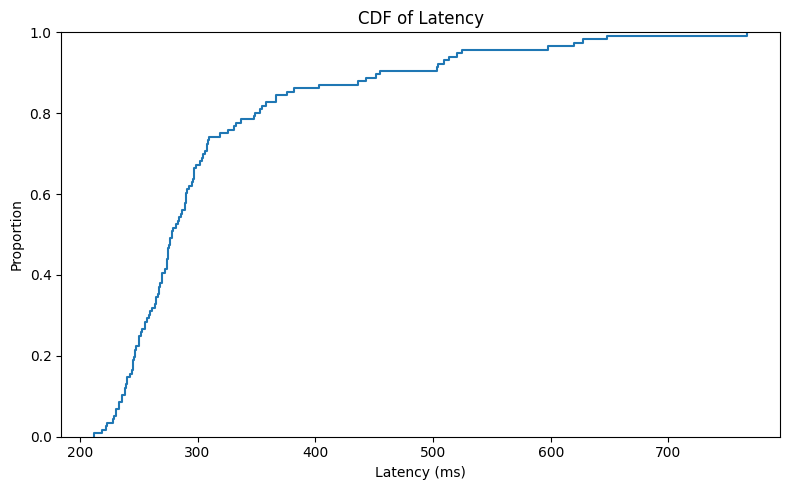

In [9]:
%matplotlib inline

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(f"./npf-out/{now}.csv")

# fig, ax = plt.subplots(figsize=(8, 5))
# sns.lineplot(
#     data=df,
#     x="ADDITIONAL_DATA_SIZE",
#     y="y_LATENCY",
#     markers=True,
#     errorbar="sd",
#     ax=ax,
# )
# ax.set_xlabel("Additional Data Size")
# ax.set_ylabel("Latency (ms)")
# ax.set_title("Latency vs Additional Data Size")
# plt.tight_layout()
# plt.savefig("latency_vs_size.png", dpi=150)
# plt.show()

# plt.figure()
fig, ax = plt.subplots(figsize=(8, 5))
sns.ecdfplot(data=df, x="y_LATENCY", ax=ax)
ax.set_xlabel("Latency (ms)")
ax.set_title("CDF of Latency")
plt.tight_layout()
# plt.savefig("latency_cdf.png", dpi=150)
plt.show()

### Stopping the current booking

In [6]:
provider.destroy()

INFO     [G5k] Reloading 277588 from luxembourg                          ]8;id=501875;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=959937;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Killing the job (luxembourg, 277588)                      ]8;id=606896;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=129375;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#276\276]8;;\

INFO     [G5k] Job killed (luxembourg, 277588)                           ]8;id=126385;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=989017;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#257\257]8;;\